24BAD073-MOHAMED ASLAM
Deepl Learning Experiment - 04

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-and-dogs-mini-dataset' dataset.
Path to dataset files: /kaggle/input/cats-and-dogs-mini-dataset


In [ ]:
import os

print("Dataset path:", path)
print("Files/Folders:")

for item in os.listdir(path):
    print(item)

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

Dataset path: /kaggle/input/cats-and-dogs-mini-dataset
Files/Folders:
dogs_set
cats_set
/kaggle/input/cats-and-dogs-mini-dataset -> 0 files
/kaggle/input/cats-and-dogs-mini-dataset/dogs_set -> 500 files
/kaggle/input/cats-and-dogs-mini-dataset/cats_set -> 500 files


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [ ]:
cat_dir = os.path.join(path, "cats_set")
dog_dir = os.path.join(path, "dogs_set")

print("Cats:", len(os.listdir(cat_dir)))
print("Dogs:", len(os.listdir(dog_dir)))

Cats: 500
Dogs: 500


In [ ]:
base_dir = "/content/cats_dogs_split"

for split in ["train", "validation", "test"]:
    for category in ["cats", "dogs"]:
        os.makedirs(
            os.path.join(base_dir, split, category),
            exist_ok=True
        )

In [ ]:
def split_images(source_dir, category):
    images = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for image in train_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "train", category, image)
        )

    for image in val_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "validation", category, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "test", category, image)
        )

    print(category)
    print("Train:", len(train_images))
    print("Validation:", len(val_images))
    print("Test:", len(test_images))

In [ ]:
split_images(cat_dir, "cats")
split_images(dog_dir, "dogs")

cats
Train: 350
Validation: 75
Test: 75
dogs
Train: 350
Validation: 75
Test: 75


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_data = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)
validation_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)
test_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 700 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


{'cats': 0, 'dogs': 1}


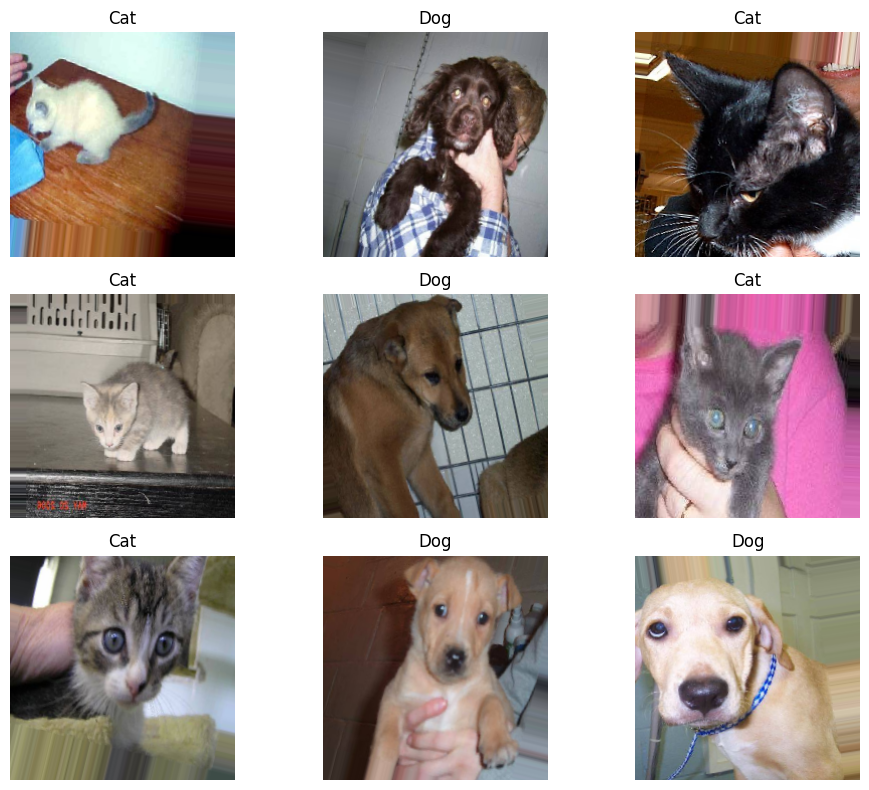

In [ ]:
print(train_data.class_indices)
images, labels = next(train_data)

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# loading the ResNet50 model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 157s 7s/step - accuracy: 0.5157 - loss: 0.7199 - val_accuracy: 0.5800 - val_loss: 0.6878
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - accuracy: 0.5214 - loss: 0.7100 - val_accuracy: 0.5000 - val_loss: 0.7018
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 164s 8s/step - accuracy: 0.5014 - loss: 0.6986 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 189s 7s/step - accuracy: 0.5443 - loss: 0.6894 - val_accuracy: 0.6000 - val_loss: 0.6859
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 156s 7s/step - accuracy: 0.5071 - loss: 0.6956 - val_accuracy: 0.5733 - val_loss: 0.6856


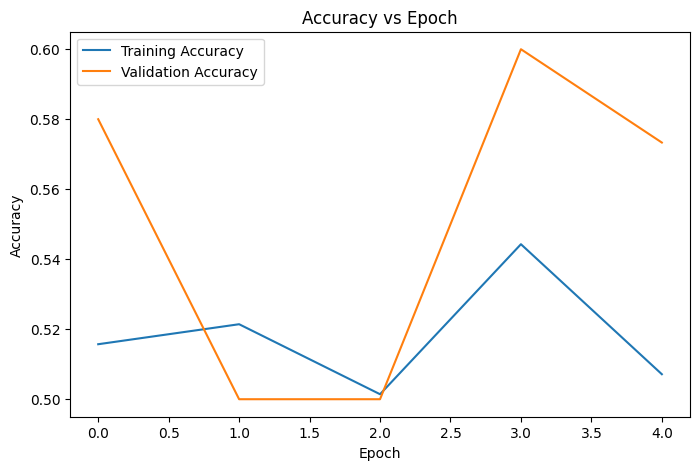

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

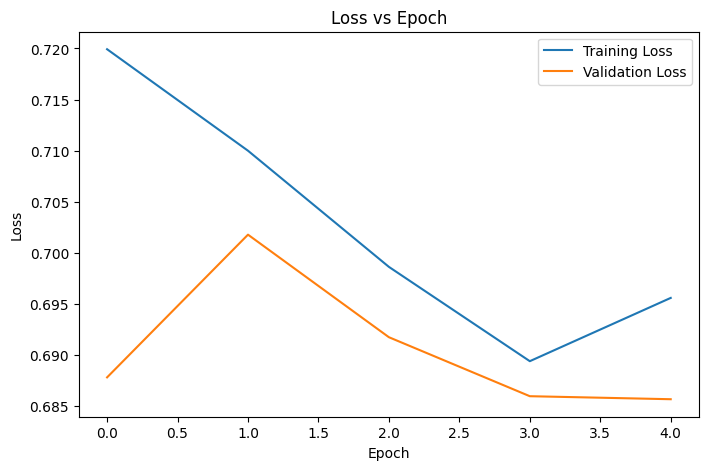

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.7267 - loss: 0.6677
Test Loss: 0.6676898002624512
Test Accuracy: 0.7266666889190674


In [ ]:
!pip install -q transformers

In [ ]:
from transformers import pipeline
from PIL import Image

In [ ]:
pipe = pipeline("image-classification", model="microsoft/resnet-50")
image="/content/cats_dogs_split/test/cats/cat.4008.jpg"
pipe("/content/cats_dogs_split/test/cats/cat.4008.jpg")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[{'label': 'Egyptian cat', 'score': 0.38060295581817627},
 {'label': 'Angora, Angora rabbit', 'score': 0.1371355950832367},
 {'label': 'chow, chow chow', 'score': 0.07194735109806061},
 {'label': 'Labrador retriever', 'score': 0.05947267636656761},
 {'label': 'shopping basket', 'score': 0.0287510696798563}]

In [ ]:
classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = Image.open(image_path)

Saving cat.4008.jpg to cat.4008.jpg


In [ ]:
predictions = classifier(
    image,
    candidate_labels=["cat", "dog"]
)

print(predictions)

[{'score': 0.8499305248260498, 'label': 'dog'}, {'score': 0.1500694453716278, 'label': 'cat'}]


In [ ]:
# Hugging Face prediction
hf_prediction = predictions[0]["label"]

# ResNet-50 prediction
img = image.resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

resnet_score = model.predict(img_array, verbose=0)[0][0]

if resnet_score >= 0.5:
    resnet_prediction = "dog"
    resnet_confidence = resnet_score
else:
    resnet_prediction = "cat"
    resnet_confidence = 1 - resnet_score

print("Hugging Face Prediction :", hf_prediction.upper())
print("Hugging Face Confidence :", round(predictions[0]["score"] * 100, 2), "%")

print()

print("ResNet-50 Prediction     :", resnet_prediction.upper())
print("ResNet-50 Confidence     :", round(resnet_confidence * 100, 2), "%")

Hugging Face Prediction : DOG
Hugging Face Confidence : 84.99 %

ResNet-50 Prediction     : CAT
ResNet-50 Confidence     : 51.16 %


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ResNet-50", "Hugging Face CLIP"],
    "Prediction": [
        resnet_prediction.upper(),
        hf_prediction.upper()
    ],
    "Confidence": [
        f"{resnet_confidence * 100:.2f}%",
        f"{predictions[0]['score'] * 100:.2f}%"
    ]
})

comparison

,Model,Prediction,Confidence
0,ResNet-50,CAT,51.16%
1,Hugging Face CLIP,DOG,84.99%
